In [1]:
# imports
import os
import matplotlib.pyplot as plt
from matplotlib import colors
import numpy as np
from mpl_toolkits.axes_grid1 import make_axes_locatable
import bioframe
import seaborn as sns
import pandas as pd 
from matplotlib.colors import LogNorm

import cooler 
import cooltools
from cooltools.lib import numutils, plotting
from cooltools.lib import plotting

import scipy
import seaborn as sns

import pandas as pd
import itertools

from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from matplotlib.colors import Normalize, LogNorm
from matplotlib import ticker
import matplotlib.pyplot as plt
from cooltools.api.saddle import saddle_strength

from cytoolz import merge

from coolpuppy import coolpup
from coolpuppy.lib import numutils
from coolpuppy.lib.puputils import divide_pups
from coolpuppy import plotpup

In [2]:
basedir = os.getcwd()
print(basedir)

%cd /home/varshini/uc_analyses/
# import compartment_calling
import utils
import compartments
%cd /home/varshini/LoopCall_Analysis_Scripts

/home/varshini/LoopCall_Analysis_Scripts/blood/complete_analyses/FigureGeneration
/home/varshini/uc_analyses
/home/varshini/LoopCall_Analysis_Scripts


In [3]:
plt.rcParams.update({
    "text.usetex": False})
plt.rcParams['svg.fonttype'] = 'none'
plt.rc('pdf',fonttype = 42)
plt.rcParams["ps.useafm"] = True


In [4]:
# filenames 
phases = ['Phase1_', 'Phase2_dedup', 'Phase3_dedup']
uc_path = '/mnt/coldstorage/Varshmallow/Adipose_Blood_Merged/sankaran'
uc_filenames = [os.path.join(uc_path, f"Sankaran_{p}merged.250.mcool") for p in phases]

uc_expected_path = '/mnt/md0/varshini/Analysis/Blood/microc_expected'
fasta_path = '/mnt/coldstorage/Varshmallow/hg38/hg38.fa'

analysis_path = '/mnt/md0/varshini/Analysis/Blood/Merged_Compartments'
if not os.path.exists(analysis_path):
    os.mkdir(analysis_path)
    
savedir='/mnt/md0/varshini/Analysis/Blood/figs_v3/supp2'
if not os.path.exists(savedir):
    os.mkdir(savedir)

In [5]:
## utils

def define_a_b(eig_df):
    df = eig_df.copy()

    phase_cols = [c for c in df.columns if c.startswith("E1_")]
    print(phase_cols)
    phase_cols = sorted(
        phase_cols,
        key=lambda x: int(x.split("_P")[-1])
    )

    # assign A/B state
    for col in phase_cols:
        phase = col.replace("E1_", "")

        df[f"{phase}_AB"] = pd.Series(
            pd.NA,
            index=df.index,
            dtype="object"
        )
        df.loc[df[col] > 0, f"{phase}_AB"] = "A"
        df.loc[df[col] < 0, f"{phase}_AB"] = "B"

        df[f"{phase}_block"] = (
            (df["chrom"] != df["chrom"].shift())
            | (df[f"{phase}_AB"] != df[f"{phase}_AB"].shift())
        ).cumsum()

    for p1, p2 in itertools.combinations(phase_cols, 2):

        ph1 = p1.replace("E1_", "")
        ph2 = p2.replace("E1_", "")

        c1 = f"{ph1}_AB"
        c2 = f"{ph2}_AB"

        switch_col = f"{ph1}_to_{ph2}"

        df[switch_col] = (
            df[c1].fillna("NA")
            + "_to_"
            + df[c2].fillna("NA")
        )

    return df

from functools import reduce 

def load_eigs(eig_df_list, phases):    
    eigs_phase = []
    
    for i, phase in enumerate(phases):
        curr_eig = eig_df_list[i]
        eigs_phase.append(curr_eig.rename(columns={c: c+f'_P{i+1}' for c in curr_eig.columns[3:]}))

    eigs_phase_merged = reduce(lambda left,right: pd.merge(left,right,on=['chrom', 'start','end'], 
                                                    how='outer'), eigs_phase)
    
    return eigs_phase_merged

In [6]:
## below is from the cooltools documentation

# plot saddle score across phases
def saddleplot(
    track,
    saddledata,
    n_bins,
    vrange=None,
    qrange=(0.0, 1.0),
    cmap="coolwarm",
    scale="log",
    vmin=0.5,
    vmax=2,
    color=None,
    title=None,
    xlabel=None,
    ylabel=None,
    clabel=None,
    fig=None,
    fig_kws=None,
    heatmap_kws=None,
    margin_kws=None,
    cbar_kws=None,
    subplot_spec=None,
):
    """
    Generate a saddle plot.
    Parameters
    ----------
    track : pd.DataFrame
        See cooltools.digitize() for details.
    saddledata : 2D array-like
        Saddle matrix produced by `make_saddle`. It will include 2 flanking
        rows/columns for outlier signal values, thus the shape should be
        `(n+2, n+2)`.
    cmap : str or matplotlib colormap
        Colormap to use for plotting the saddle heatmap
    scale : str
        Color scaling to use for plotting the saddle heatmap: log or linear
    vmin, vmax : float
        Value limits for coloring the saddle heatmap
    color : matplotlib color value
        Face color for margin bar plots
    fig : matplotlib Figure, optional
        Specified figure to plot on. A new figure is created if none is
        provided.
    fig_kws : dict, optional
        Passed on to `plt.Figure()`
    heatmap_kws : dict, optional
        Passed on to `ax.imshow()`
    margin_kws : dict, optional
        Passed on to `ax.bar()` and `ax.barh()`
    cbar_kws : dict, optional
        Passed on to `plt.colorbar()`
    subplot_spec : GridSpec object
        Specify a subregion of a figure to using a GridSpec.
    Returns
    -------
    Dictionary of axes objects.
    """

#     warnings.warn(
#         "Generating a saddleplot will be deprecated in future versions, "
#         + "please see https://github.com/open2c_examples for examples on how to plot saddles.",
#         DeprecationWarning,
#     )

    from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
    from matplotlib.colors import Normalize, LogNorm
    from matplotlib import ticker
    import matplotlib.pyplot as plt

    class MinOneMaxFormatter(ticker.LogFormatter):
        def set_locs(self, locs=None):
            self._sublabels = set([vmin % 10 * 10, vmax % 10, 1])

        def __call__(self, x, pos=None):
            if x not in [vmin, 1, vmax]:
                return ""
            else:
                return "{x:g}".format(x=x)

    track_value_col = track.columns[3]
    track_values = track[track_value_col].values

    digitized_track, binedges = cooltools.digitize(
        track, n_bins, vrange=vrange, qrange=qrange
    )
    x = digitized_track[digitized_track.columns[3]].values.astype(int).copy()
    x = x[(x > -1) & (x < len(binedges) + 1)]

    # Old version
    # hist = np.bincount(x, minlength=len(binedges) + 1)

    groupmean = track[track.columns[3]].groupby(digitized_track[digitized_track.columns[3]]).mean()

    if qrange is not None:
        lo, hi = qrange
        binedges = np.linspace(lo, hi, n_bins + 1)

    # Barplot of mean values and saddledata are flanked by outlier bins
    n = saddledata.shape[0]
    X, Y = np.meshgrid(binedges, binedges)
    C = saddledata
    if (n - n_bins) == 2:
        C = C[1:-1, 1:-1]
        groupmean = groupmean[1:-1]

    # Layout
    if subplot_spec is not None:
        GridSpec = partial(GridSpecFromSubplotSpec, subplot_spec=subplot_spec)
    grid = {}
    gs = GridSpec(
        nrows=3,
        ncols=3,
        width_ratios=[0.2, 1, 0.1],
        height_ratios=[0.2, 1, 0.1],
        wspace=0.05,
        hspace=0.05,
    )

    # Figure
    if fig is None:
        fig_kws_default = dict(figsize=(5, 5))
        fig_kws = merge(fig_kws_default, fig_kws if fig_kws is not None else {})
        fig = plt.figure(**fig_kws)

    # Heatmap
    if scale == "log":
        norm = LogNorm(vmin=vmin, vmax=vmax)
    elif scale == "linear":
        norm = Normalize(vmin=vmin, vmax=vmax)
    else:
        raise ValueError("Only linear and log color scaling is supported")

    grid["ax_heatmap"] = ax = plt.subplot(gs[4])
    heatmap_kws_default = dict(cmap="coolwarm", rasterized=True)
    heatmap_kws = merge(
        heatmap_kws_default, heatmap_kws if heatmap_kws is not None else {}
    )
    img = ax.pcolormesh(X, Y, C, norm=norm, **heatmap_kws)
    plt.gca().yaxis.set_visible(False)

    # Margins
    margin_kws_default = dict(edgecolor="k", facecolor=color, linewidth=1)
    margin_kws = merge(margin_kws_default, margin_kws if margin_kws is not None else {})
    # left margin hist
    grid["ax_margin_y"] = plt.subplot(gs[3], sharey=grid["ax_heatmap"])

    plt.barh(
        binedges, height=1/len(binedges), width=groupmean, align="edge", **margin_kws
    )

    plt.xlim(plt.xlim()[1], plt.xlim()[0])  # fliplr
    plt.ylim(hi, lo)
    plt.gca().spines["top"].set_visible(False)
    plt.gca().spines["bottom"].set_visible(False)
    plt.gca().spines["left"].set_visible(False)
    plt.gca().xaxis.set_visible(False)
    # top margin hist
    grid["ax_margin_x"] = plt.subplot(gs[1], sharex=grid["ax_heatmap"])

    plt.bar(
        binedges, width=1/len(binedges), height=groupmean, align="edge", **margin_kws
    )

    plt.xlim(lo, hi)
    # plt.ylim(plt.ylim())  # correct
    plt.gca().spines["top"].set_visible(False)
    plt.gca().spines["right"].set_visible(False)
    plt.gca().spines["left"].set_visible(False)
    plt.gca().xaxis.set_visible(False)
    plt.gca().yaxis.set_visible(False)

#     # Colorbar
    grid["ax_cbar"] = plt.subplot(gs[5])
    cbar_kws_default = dict(fraction=0.8, label=clabel or "")
    cbar_kws = merge(cbar_kws_default, cbar_kws if cbar_kws is not None else {})
    if scale == "linear" and vmin is not None and vmax is not None:
        grid["ax_cbar"] = cb = plt.colorbar(img, **cbar_kws)
        # cb.set_ticks(np.arange(vmin, vmax + 0.001, 0.5))
        # # do linspace between vmin and vmax of 5 segments and trunc to 1 decimal:
        decimal = 10
        nsegments = 5
        cd_ticks = np.trunc(np.linspace(vmin, vmax, nsegments) * decimal) / decimal
        cb.set_ticks(cd_ticks)
    else:
        print('cbar')

        cb = plt.colorbar(img, format=MinOneMaxFormatter(), cax=grid["ax_cbar"], **cbar_kws)
        cb.ax.yaxis.set_minor_formatter(MinOneMaxFormatter())

    # extra settings
    grid["ax_heatmap"].set_xlim(lo, hi)
    grid["ax_heatmap"].set_ylim(hi, lo)
    grid['ax_heatmap'].grid(False)
    if title is not None:
        grid["ax_margin_x"].set_title(title)
    if xlabel is not None:
        grid["ax_heatmap"].set_xlabel(xlabel)
    if ylabel is not None:
        grid["ax_margin_y"].set_ylabel(ylabel)

    return grid

# saddle plot
def run_saddleplot(eigs_new, uc_coolers, uc_exp_fnames, res, Q_LO=0.025, Q_HI=0.975, N_GROUPS=38, sd=None):
    i=0
    plt.figure()
    for clr, expname in zip(uc_coolers, uc_exp_fnames):
        view_df = utils.get_hg38_arms()
        if not (os.path.exists(os.path.join(uc_expected_path,expname))):
            cvd = cooltools.expected_cis(clr=clr, smooth=True, view_df=view_df, aggregate_smoothed=True, nproc=8)
            cvd.to_csv(os.path.join(uc_expected_path,expname), index=False, sep='\t')
        else:
            cvd=pd.read_csv(os.path.join(uc_expected_path,expname), sep='\t')

        interaction_sum, interaction_count =  cooltools.saddle(
                clr,
                cvd,
                eigs_new[i][['chrom','start','end', 'E1']], 'cis',
                n_bins=N_GROUPS,
                qrange=(Q_LO,Q_HI),
                view_df=view_df
        )
    

        # at extent=0, this reduces to ((S/C)[0,0] + (S/C)[-1,-1]) / (2*(S/C)[-1,0])
        x = np.arange(N_GROUPS + 2)

        saddleplot(eigs_new[i][['chrom','start','end', 'E1']],
                   interaction_sum/interaction_count,
                   N_GROUPS,
                   qrange=(Q_LO,Q_HI),
                   cbar_kws={'label':'average observed/expected contact frequency'}
                  );

        if sd:
            plt.savefig(os.path.join(sd, f"saddle_{res//1000}kb_P{i+1}.svg"))
        else:
            plt.show()

        i+=1


In [7]:
# modified from the coolpuppy documentation

def run_pileups(eig_annot, uc_coolers, uc_exp_fnames, res, nint = 10, phases=('P1', 'P2', 'P3'), 
                sd=None, vmax=1.4):
    a_compts = {}
    b_compts = {}
    
    hg38_arms = utils.get_hg38_arms()
    
    for i, p in enumerate(phases):
        A_compartments = bioframe.merge(eig_annot[eig_annot[f"E1_{p}"] > 0], 
                                        min_dist=0)
        A_compartments = A_compartments[A_compartments["n_intervals"] >= nint]
        
        B_compartments = bioframe.merge(eig_annot[eig_annot[f"E1_{p}"] < 0], 
                                        min_dist=0)
        B_compartments = B_compartments[B_compartments["n_intervals"] >= nint]
        
        ##
        pup = coolpup.pileup(uc_coolers[i], A_compartments, features_format='bed', view_df=hg38_arms,
                                expected_df=pd.read_csv(os.path.join(uc_expected_path,uc_exp_fnames[i]), sep='\t'),
                                rescale=True, rescale_flank=1, rescale_size=99,
                                nproc=2)
        a_compts[p] = pup
        
        fg = plotpup.plot(pup,
                         score=True, cmap='coolwarm', scale='log', sym=True, height=5, vmax=vmax)
        if sd:
            fg.savefig(os.path.join(savedir, f"{p}_{res//1000}kb_Acompt_pileup.svg"))
        fg
        
        ##
        pupb = coolpup.pileup(uc_coolers[i], B_compartments, features_format='bed', view_df=hg38_arms,
                                expected_df=pd.read_csv(os.path.join(uc_expected_path,uc_exp_fnames[i]), sep='\t'),
                                rescale=True, rescale_flank=1, rescale_size=99,
                                nproc=2)
        b_compts[p] = pupb
        fgb = plotpup.plot(pupb,
                         score=True, cmap='coolwarm', scale='log', sym=True, height=5, vmax=vmax)
        if sd:
            fgb.savefig(os.path.join(savedir, f"{p}_{res//1000}b_Bcompt_pileup.svg"))
        fgb
    
    return a_compts, b_compts

## 10kb compartments

In [12]:
resolution = 10_000
uc_coolers = [utils.get_clr(clr_name, resolution) for clr_name in uc_filenames]
uc_exp_fnames = [f"P_s_{f.split('/')[-1].split('.')[0]}_{resolution}bp_hg38arms.tsv" for f in uc_filenames]

cov_fnames = [os.path.join(analysis_path, f'{phase}_hg38_gc_cov_{int(resolution/1000)}kb.tsv') for phase in phases]
eigs_fnames = [os.path.join(analysis_path, f'eigs_P{phase}_{int(resolution/1000)}kb.tsv') for phase in phases]

cov_tags = [f'{phase}_hg38_gc_cov' for phase in phases]
eig_tags = [f'{phase}' for phase in phases]

clr = uc_coolers[0]
cov = cov_tags[0]

gc_cov = compartments.get_gc_cov(analysis_path, cov, resolution, clr, fasta_path=fasta_path)

eigs_new = [compartments.get_eigen_decomp(analysis_path, eig_tags[i], gc_cov, uc_coolers[i], res=resolution, idx=3) for i in range(3)]

## Figure 1, Compartment example with subtracted eigenvector

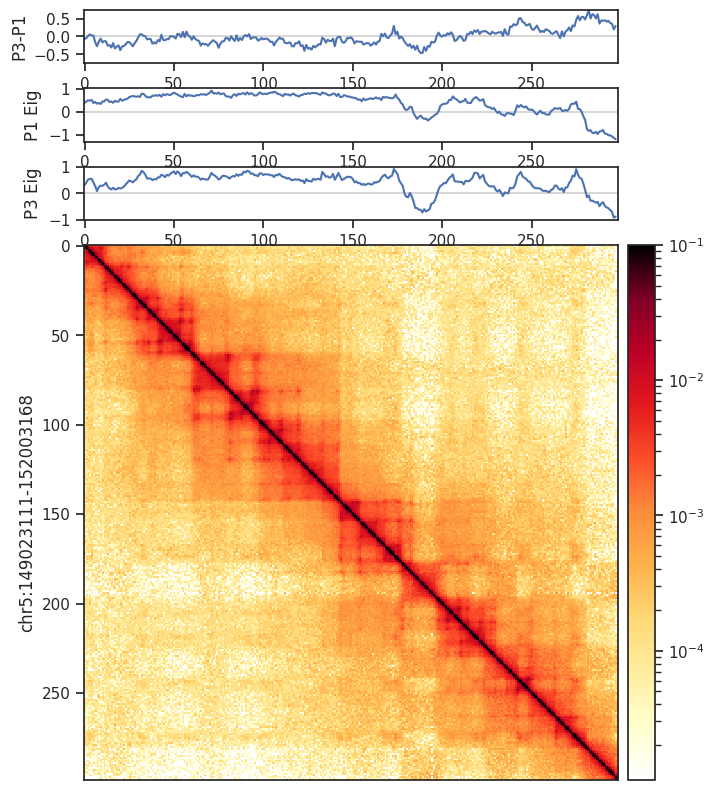

In [151]:
reg = 'chr5:149023111-152003168'
chrom, st, ed = utils.get_coords(reg)

i = st//resolution
j = ed//resolution

curr_clr_mat = uc_coolers[2].matrix(balance=True).fetch(reg)

eig_p1 = eigs_new[0][eigs_new[0]['chrom']==chrom]['E1'].values
eig_p3 = eigs_new[2][eigs_new[2]['chrom']==chrom]['E1'].values

eig_p31 = eig_p3 - eig_p1
norm=colors.LogNorm(vmax=0.1)
f, ax = plt.subplots(
    figsize=(15, 10),
)

im = ax.matshow(
    curr_clr_mat,
    norm=norm,
    cmap='fall');

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)
plt.colorbar(im, cax=cax);
ax.set_ylabel(reg)
ax.xaxis.set_visible(False)

ax1 = divider.append_axes("top", size="10%", pad=0.25, sharex=ax)
ax1.plot([0,j-i],[0,0],'k',lw=0.25)
ax1.plot(eig_p3[i:j])
ax1.set_ylabel('P3 Eig')

ax2 = divider.append_axes("top", size="10%", pad=0.25, sharex=ax)
ax2.plot([0,j-i],[0,0],'k',lw=0.25)
ax2.plot(eig_p1[i:j])
ax2.set_ylabel('P1 Eig')

ax3 = divider.append_axes("top", size="10%", pad=0.25, sharex=ax)
ax3.plot([0,j-i],[0,0],'k',lw=0.25)
ax3.plot(eig_p3[i:j]-eig_p1[i:j])
ax3.set_ylim([-0.75, 0.75])
ax3.set_ylabel('P3-P1')

plt.savefig(os.path.join(savedir, "eigvecs_compt_1_diff_both.svg"))
plt.show()

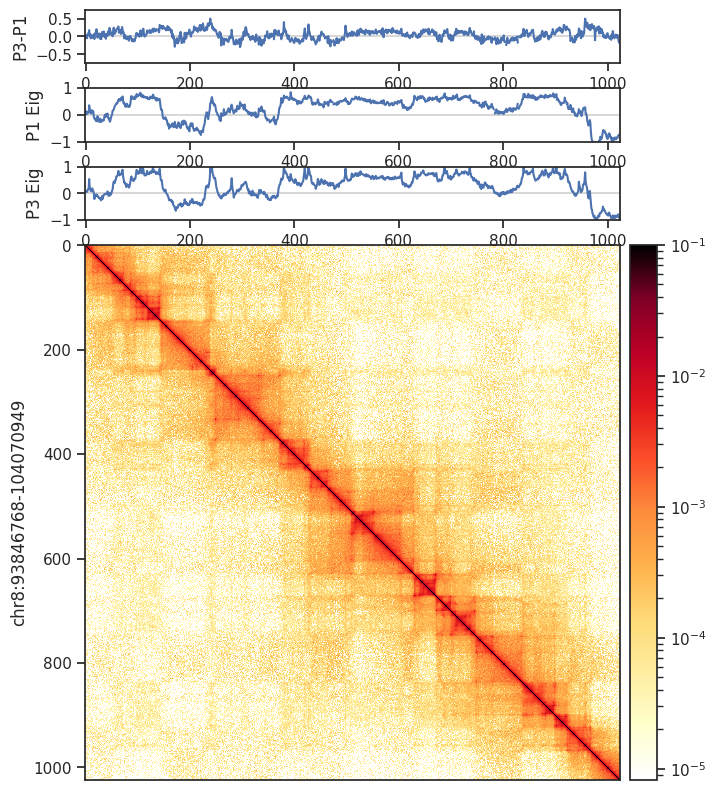

In [152]:
# Another 10kb example

reg = 'chr8:93846768-104070949'
chrom, st, ed = utils.get_coords(reg)

i = st//resolution
j = ed//resolution

curr_clr_mat = uc_coolers[2].matrix(balance=True).fetch(reg)

eig_p1 = eigs_new[0][eigs_new[0]['chrom']==chrom]['E1'].values
eig_p3 = eigs_new[2][eigs_new[2]['chrom']==chrom]['E1'].values

eig_p31 = eig_p3 - eig_p1
norm=colors.LogNorm(vmax=0.1)
f, ax = plt.subplots(
    figsize=(15, 10),
)

im = ax.matshow(
    curr_clr_mat,
    norm=norm,
    cmap='fall');

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)
plt.colorbar(im, cax=cax);
ax.set_ylabel(reg)
ax.xaxis.set_visible(False)

ax1 = divider.append_axes("top", size="10%", pad=0.25, sharex=ax)
ax1.plot([0,j-i],[0,0],'k',lw=0.25)
ax1.plot(eig_p3[i:j])
ax1.set_ylim([-1, 1])
ax1.set_ylabel('P3 Eig')

ax2 = divider.append_axes("top", size="10%", pad=0.25, sharex=ax)
ax2.plot([0,j-i],[0,0],'k',lw=0.25)
ax2.plot(eig_p1[i:j])
ax2.set_ylim([-1, 1])
ax2.set_ylabel('P1 Eig')

ax3 = divider.append_axes("top", size="10%", pad=0.25, sharex=ax)
ax3.plot([0,j-i],[0,0],'k',lw=0.25)
ax3.plot(eig_p3[i:j]-eig_p1[i:j])
ax3.set_ylim([-0.75, 0.75])
ax3.set_ylabel('P3-P1')


plt.savefig(os.path.join(savedir, "eigvecs_compt_3sub_diff_both.svg"))
plt.show()

['E1_P1', 'E1_P2', 'E1_P3']


<AxesSubplot:xlabel='phase transition', ylabel='value'>

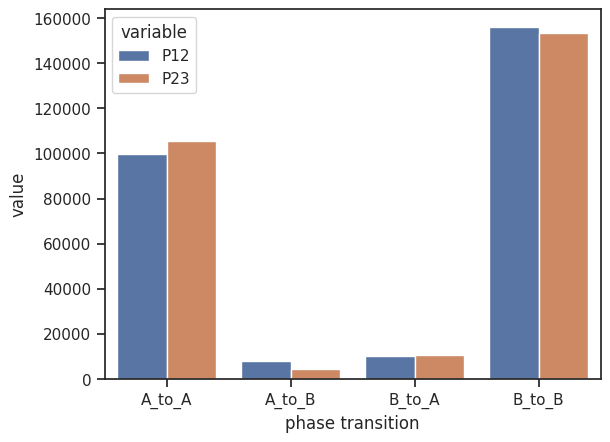

In [13]:
eigs_phase = load_eigs(eigs_new, ['P1','P2','P3'])
eig_annot = define_a_b(eigs_phase.dropna().sort_values(by = ['chrom','start','end']))

P_transition = pd.merge(eig_annot.groupby('P1_to_P2').agg(P12 = ('P1_to_P2', 'count')), 
                         eig_annot.groupby('P2_to_P3').agg(P23 = ('P2_to_P3', 'count')), left_index=True, right_index=True)

eig_melt = P_transition.melt(ignore_index=False)
eig_melt['phase transition'] = eig_melt.index

sns.barplot(data=eig_melt, x='phase transition', y='value', hue='variable')

In [108]:
eig_annot

,chrom,start,end,weight_P1,E1_P1,E2_P1,E3_P1,weight_P2,E1_P2,E2_P2,...,E3_P3,P1_AB,P1_block,P2_AB,P2_block,P3_AB,P3_block,P1_to_P2,P1_to_P3,P2_to_P3
82,chr1,820000,830000,0.007398,0.635239,-0.027273,-0.442623,0.006887,0.741985,0.131486,...,0.015388,A,1,A,1,A,1,A_to_A,A_to_A,A_to_A
83,chr1,830000,840000,0.017315,0.841765,-0.074313,-0.287612,0.015754,0.866224,0.076343,...,0.087851,A,1,A,1,A,1,A_to_A,A_to_A,A_to_A
84,chr1,840000,850000,0.012743,0.674894,-0.190898,-0.242914,0.011678,0.825647,0.039553,...,-0.054651,A,1,A,1,A,1,A_to_A,A_to_A,A_to_A
86,chr1,860000,870000,0.012061,0.760830,-0.154721,-0.336260,0.011670,0.868541,-0.017520,...,0.047694,A,1,A,1,A,1,A_to_A,A_to_A,A_to_A
87,chr1,870000,880000,0.008213,0.785043,-0.059523,-0.266521,0.007753,0.769258,-0.056549,...,0.076778,A,1,A,1,A,1,A_to_A,A_to_A,A_to_A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
308798,chrY,56840000,56850000,0.014829,-0.970005,-0.099240,-0.006282,0.013403,-0.930136,0.432545,...,-0.172135,B,8436,B,10343,B,9349,B_to_B,B_to_B,B_to_B
308799,chrY,56850000,56860000,0.013290,-0.985240,-0.087667,-0.064339,0.012283,-0.968232,0.308014,...,-0.118149,B,8436,B,10343,B,9349,B_to_B,B_to_B,B_to_B
308800,chrY,56860000,56870000,0.016961,-0.988148,0.056072,0.000068,0.016152,-0.989550,-0.043578,...,-0.429583,B,8436,B,10343,B,9349,B_to_B,B_to_B,B_to_B
308801,chrY,56870000,56880000,0.016933,-0.980069,0.026421,-0.035271,0.017110,-0.934782,-0.026386,...,-0.044463,B,8436,B,10343,B,9349,B_to_B,B_to_B,B_to_B


/home/varshini/anaconda3/lib/python3.9/site-packages/cooltools/api/saddle.py:92: RuntimeWarning: invalid value encountered in divide
  return obs_mat / exp_mat


cbar


/home/varshini/anaconda3/lib/python3.9/site-packages/cooltools/api/saddle.py:92: RuntimeWarning: invalid value encountered in divide
  return obs_mat / exp_mat


cbar


/home/varshini/anaconda3/lib/python3.9/site-packages/cooltools/api/saddle.py:92: RuntimeWarning: invalid value encountered in divide
  return obs_mat / exp_mat


cbar


<Figure size 640x480 with 0 Axes>

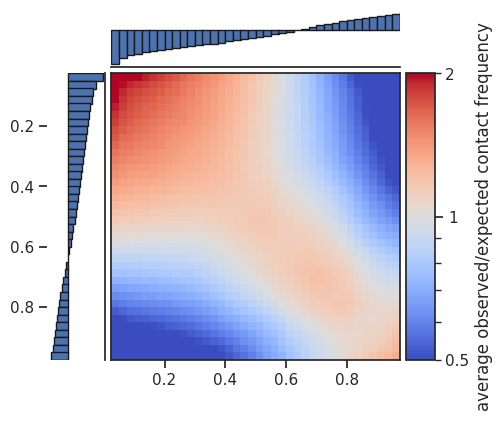

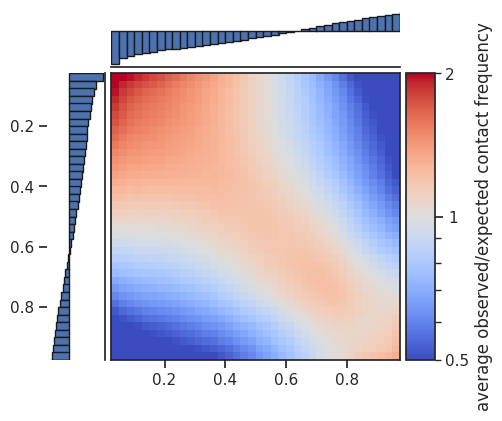

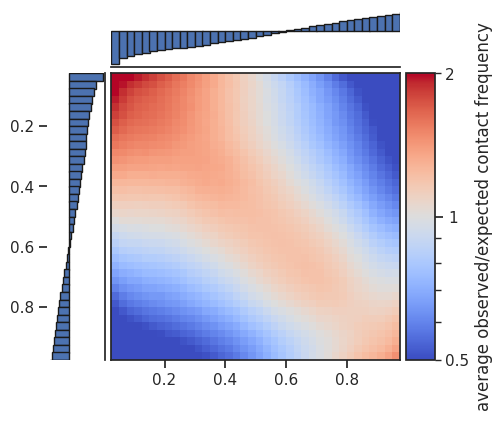

In [110]:
run_saddleplot(eigs_new, uc_coolers, uc_exp_fnames, sd=savedir, res=resolution)

INFO:coolpuppy:Rescaling with rescale_flank = 1 to 99x99 pixels
INFO:coolpuppy:('chr4_p', 'chr4_p'): 66
INFO:coolpuppy:('chr1_p', 'chr1_p'): 171
INFO:coolpuppy:('chr4_q', 'chr4_q'): 276
INFO:coolpuppy:('chr5_p', 'chr5_p'): 15
INFO:coolpuppy:('chr1_q', 'chr1_q'): 105
INFO:coolpuppy:('chr5_q', 'chr5_q'): 231
INFO:coolpuppy:('chr2_p', 'chr2_p'): 91
INFO:coolpuppy:('chr6_p', 'chr6_p'): 136
INFO:coolpuppy:('chr6_q', 'chr6_q'): 66
INFO:coolpuppy:('chr2_q', 'chr2_q'): 276
INFO:coolpuppy:('chr7_p', 'chr7_p'): 55
INFO:coolpuppy:('chr7_q', 'chr7_q'): 120
INFO:coolpuppy:('chr3_p', 'chr3_p'): 105
INFO:coolpuppy:('chr8_p', 'chr8_p'): 45
INFO:coolpuppy:('chr3_q', 'chr3_q'): 190
INFO:coolpuppy:('chr8_q', 'chr8_q'): 136
INFO:coolpuppy:('chr9_p', 'chr9_p'): 15
INFO:coolpuppy:('chr10_p', 'chr10_p'): 45
INFO:coolpuppy:('chr9_q', 'chr9_q'): 36
INFO:coolpuppy:('chr10_q', 'chr10_q'): 66
INFO:coolpuppy:('chr11_p', 'chr11_p'): 28
INFO:coolpuppy:('chr13_q', 'chr13_q'): 55
INFO:coolpuppy:('chr11_q', 'chr11_q'):

INFO:coolpuppy:('chr4_p', 'chr4_p'): 6
INFO:coolpuppy:('chr1_p', 'chr1_p'): 561
INFO:coolpuppy:('chr4_q', 'chr4_q'): 1326
INFO:coolpuppy:('chr1_q', 'chr1_q'): 561
INFO:coolpuppy:('chr5_p', 'chr5_p'): 136
INFO:coolpuppy:('chr2_p', 'chr2_p'): 325
INFO:coolpuppy:('chr5_q', 'chr5_q'): 946
INFO:coolpuppy:('chr6_p', 'chr6_p'): 78
INFO:coolpuppy:('chr2_q', 'chr2_q'): 1081
INFO:coolpuppy:('chr6_q', 'chr6_q'): 1378
INFO:coolpuppy:('chr3_p', 'chr3_p'): 465
INFO:coolpuppy:('chr7_p', 'chr7_p'): 136
INFO:coolpuppy:('chr3_q', 'chr3_q'): 630
INFO:coolpuppy:('chr7_q', 'chr7_q'): 435
INFO:coolpuppy:('chr10_p', 'chr10_p'): 55
INFO:coolpuppy:('chr8_p', 'chr8_p'): 21
INFO:coolpuppy:('chr10_q', 'chr10_q'): 496
INFO:coolpuppy:('chr11_p', 'chr11_p'): 105
INFO:coolpuppy:('chr8_q', 'chr8_q'): 741
INFO:coolpuppy:('chr9_p', 'chr9_p'): 120
INFO:coolpuppy:('chr11_q', 'chr11_q'): 351
INFO:coolpuppy:('chr9_q', 'chr9_q'): 276
INFO:coolpuppy:('chr12_p', 'chr12_p'): 36
INFO:coolpuppy:('chr12_q', 'chr12_q'): 435
INFO:co

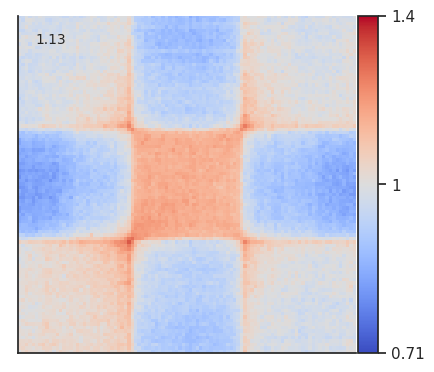

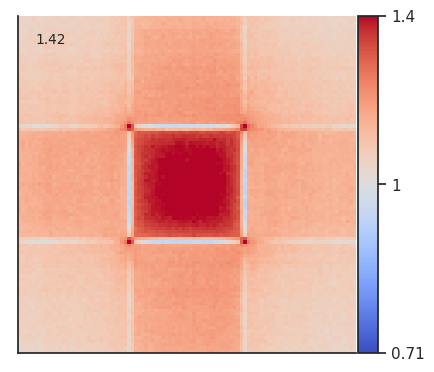

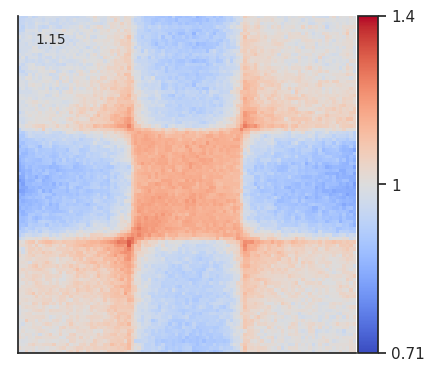

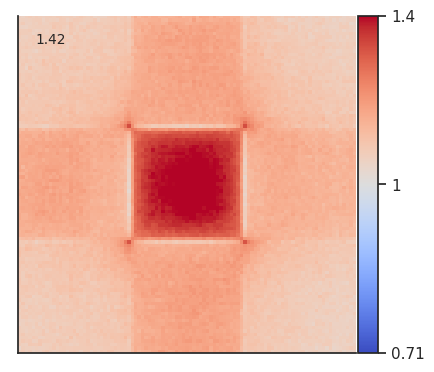

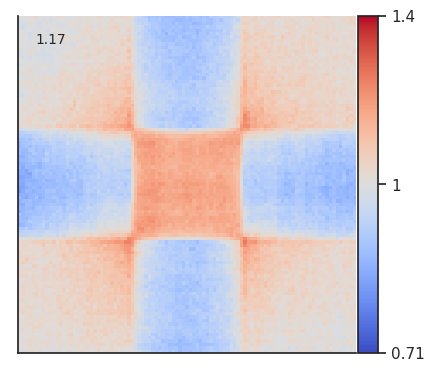

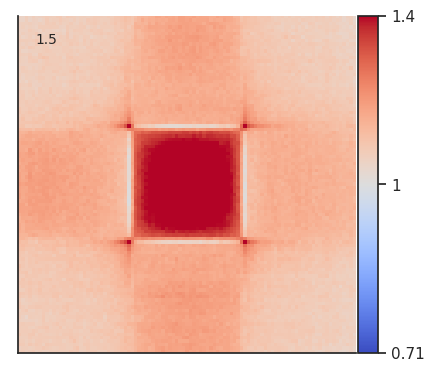

In [14]:
a_compts, b_compts = run_pileups(eig_annot, uc_coolers, uc_exp_fnames, res=resolution, nint=50, sd=None)
# origin version has nint=10

In [ ]:
## Coarser 100kb compartments

In [8]:
resolution = 100_000
uc_coolers = [utils.get_clr(clr_name, resolution) for clr_name in uc_filenames]
uc_exp_fnames = [f"P_s_{f.split('/')[-1].split('.')[0]}_{resolution}bp_hg38arms.tsv" for f in uc_filenames]

cov_fnames = [os.path.join(analysis_path, f'{phase}_hg38_gc_cov_{int(resolution/1000)}.tsv') for phase in phases]
eigs_fnames = [os.path.join(analysis_path, f'eigs_P{phase}_{int(resolution/1000)}kb.tsv') for phase in phases]

cov_tags = [f'{phase}_hg38_gc_cov' for phase in phases]
eig_tags = [f'{phase}' for phase in phases]

clr = uc_coolers[0]
cov = cov_tags[0]

gc_cov = compartments.get_gc_cov(analysis_path, cov, resolution, clr, fasta_path=fasta_path)

eigs_new = [compartments.get_eigen_decomp(analysis_path, eig_tags[i], gc_cov, uc_coolers[i], res=resolution, idx=3) for i in range(3)]

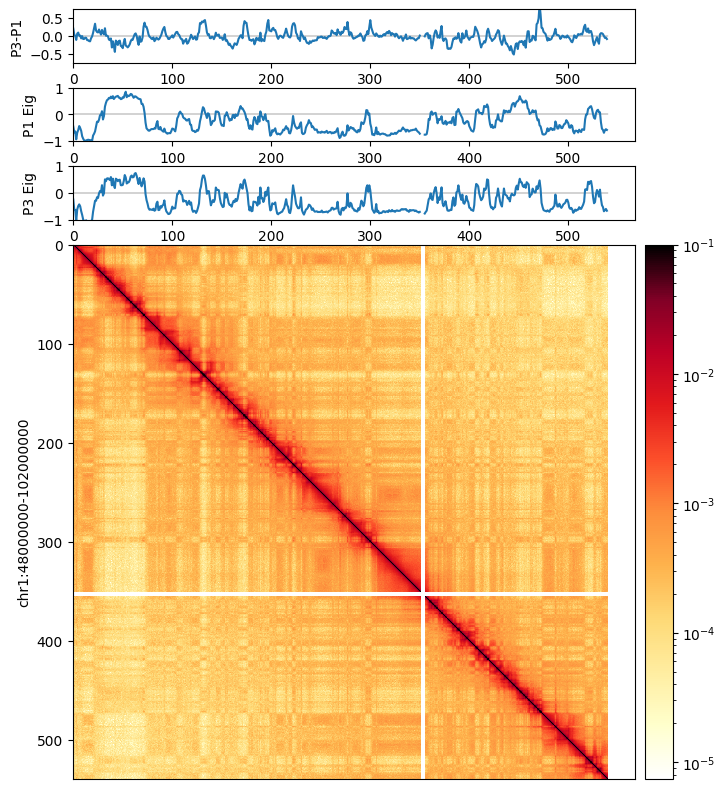

In [9]:
reg = 'chr1:48000000-102000000'
chrom, st, ed = utils.get_coords(reg)

i = st//resolution
j = ed//resolution

curr_clr_mat = uc_coolers[2].matrix(balance=True).fetch(reg)

eig_p1 = eigs_new[0][eigs_new[0]['chrom']==chrom]['E1'].values
eig_p3 = eigs_new[2][eigs_new[2]['chrom']==chrom]['E1'].values

eig_p31 = eig_p3 - eig_p1
norm=colors.LogNorm(vmax=0.1)
f, ax = plt.subplots(
    figsize=(15, 10),
)

im = ax.matshow(
    curr_clr_mat,
    norm=norm,
    cmap='fall');

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)
plt.colorbar(im, cax=cax);
ax.set_ylabel(reg)
ax.xaxis.set_visible(False)

ax1 = divider.append_axes("top", size="10%", pad=0.25, sharex=ax)
ax1.plot([0,j-i],[0,0],'k',lw=0.25)
ax1.plot(eig_p3[i:j])
ax1.set_ylim([-1, 1])
ax1.set_ylabel('P3 Eig')

ax2 = divider.append_axes("top", size="10%", pad=0.25, sharex=ax)
ax2.plot([0,j-i],[0,0],'k',lw=0.25)
ax2.plot(eig_p1[i:j])
ax2.set_ylim([-1, 1])
ax2.set_ylabel('P1 Eig')

ax3 = divider.append_axes("top", size="10%", pad=0.25, sharex=ax)
ax3.plot([0,j-i],[0,0],'k',lw=0.25)
ax3.plot(eig_p3[i:j]-eig_p1[i:j])
ax3.set_ylim([-0.75, 0.75])
ax3.set_ylabel('P3-P1')

plt.savefig(os.path.join(savedir, "eigvecs_compt_2_diff_both.svg"))
plt.show()


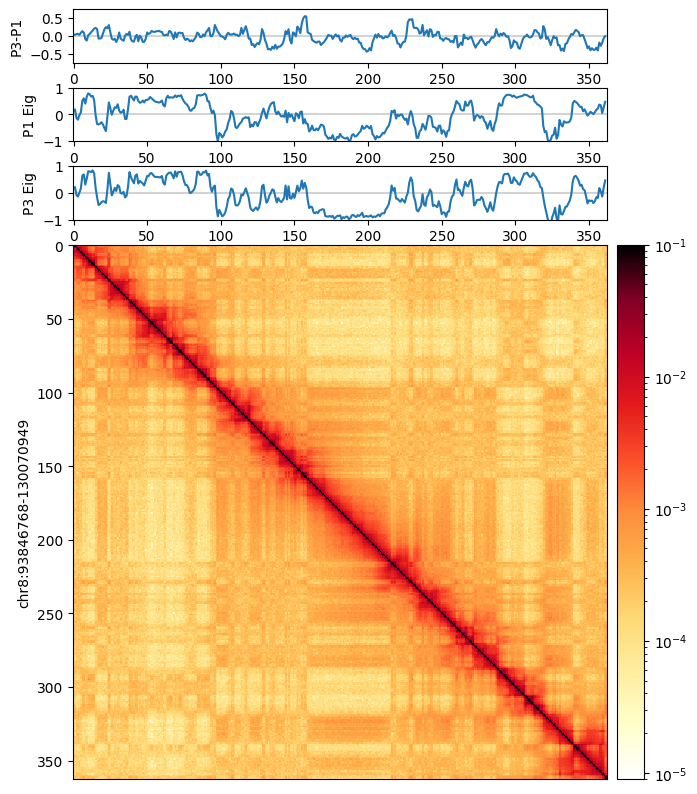

In [10]:
reg = "chr8:93846768-130070949"
chrom, st, ed = utils.get_coords(reg)

i = st//resolution
j = ed//resolution

curr_clr_mat = uc_coolers[2].matrix(balance=True).fetch(reg)

eig_p1 = eigs_new[0][eigs_new[0]['chrom']==chrom]['E1'].values
eig_p3 = eigs_new[2][eigs_new[2]['chrom']==chrom]['E1'].values

eig_p31 = eig_p3 - eig_p1
norm=colors.LogNorm(vmax=0.1)
f, ax = plt.subplots(
    figsize=(15, 10),
)

im = ax.matshow(
    curr_clr_mat,
    norm=norm,
    cmap='fall');

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)
plt.colorbar(im, cax=cax);
ax.set_ylabel(reg)
ax.xaxis.set_visible(False)

ax1 = divider.append_axes("top", size="10%", pad=0.25, sharex=ax)
ax1.plot([0,j-i],[0,0],'k',lw=0.25)
ax1.plot(eig_p3[i:j])
ax1.set_ylim([-1, 1])

ax1.set_ylabel('P3 Eig')
ax2 = divider.append_axes("top", size="10%", pad=0.25, sharex=ax)
ax2.plot([0,j-i],[0,0],'k',lw=0.25)
ax2.plot(eig_p1[i:j])
ax2.set_ylim([-1, 1])

ax2.set_ylabel('P1 Eig')

ax3 = divider.append_axes("top", size="10%", pad=0.25, sharex=ax)
ax3.plot([0,j-i],[0,0],'k',lw=0.25)
ax3.plot(eig_p3[i:j]-eig_p1[i:j])
ax3.set_ylim([-0.75, 0.75])
ax3.set_ylabel('P3-P1')

plt.savefig(os.path.join(savedir, "eigvecs_compt_3_diff_both.svg"))
plt.show()


['E1_P1', 'E1_P2', 'E1_P3']


<AxesSubplot:xlabel='phase transition', ylabel='value'>

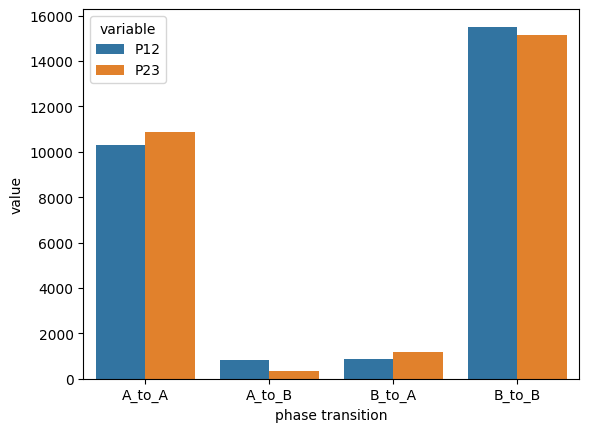

In [11]:
eigs_phase = load_eigs(eigs_new, ['P1','P2','P3'])
eig_annot = define_a_b(eigs_phase.dropna().sort_values(by = ['chrom','start','end']))

P_transition = pd.merge(eig_annot.groupby('P1_to_P2').agg(P12 = ('P1_to_P2', 'count')), 
                         eig_annot.groupby('P2_to_P3').agg(P23 = ('P2_to_P3', 'count')), left_index=True, right_index=True)

eig_melt = P_transition.melt(ignore_index=False)
eig_melt['phase transition'] = eig_melt.index

sns.barplot(data=eig_melt, x='phase transition', y='value', hue='variable')

In [12]:
uc_exp_fnames

['P_s_Sankaran_Phase1_merged_100000bp_hg38arms.tsv',
 'P_s_Sankaran_Phase2_dedupmerged_100000bp_hg38arms.tsv',
 'P_s_Sankaran_Phase3_dedupmerged_100000bp_hg38arms.tsv']

/home/varshini/anaconda3/lib/python3.9/site-packages/cooltools/api/saddle.py:92: RuntimeWarning: invalid value encountered in divide
  return obs_mat / exp_mat


cbar


/home/varshini/anaconda3/lib/python3.9/site-packages/cooltools/api/saddle.py:92: RuntimeWarning: invalid value encountered in divide
  return obs_mat / exp_mat


cbar


/home/varshini/anaconda3/lib/python3.9/site-packages/cooltools/api/saddle.py:92: RuntimeWarning: invalid value encountered in divide
  return obs_mat / exp_mat


cbar


<Figure size 640x480 with 0 Axes>

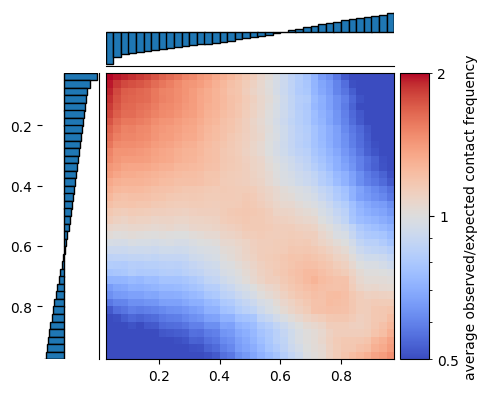

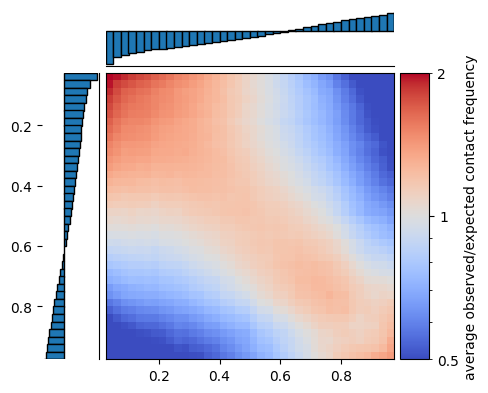

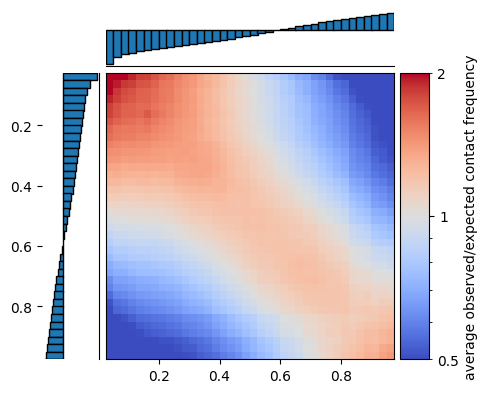

In [13]:
run_saddleplot(eigs_new, uc_coolers, uc_exp_fnames, resolution, sd=savedir)

INFO:coolpuppy:Rescaling with rescale_flank = 1 to 99x99 pixels
INFO:coolpuppy:('chr4_p', 'chr4_p'): 6
INFO:coolpuppy:('chr1_p', 'chr1_p'): 105
INFO:coolpuppy:('chr4_q', 'chr4_q'): 325
INFO:coolpuppy:('chr1_q', 'chr1_q'): 171
INFO:coolpuppy:('chr5_p', 'chr5_p'): 28
INFO:coolpuppy:('chr2_p', 'chr2_p'): 78
INFO:coolpuppy:('chr5_q', 'chr5_q'): 351
INFO:coolpuppy:('chr6_p', 'chr6_p'): 78
INFO:coolpuppy:('chr2_q', 'chr2_q'): 253
INFO:coolpuppy:('chr6_q', 'chr6_q'): 45
INFO:coolpuppy:('chr3_p', 'chr3_p'): 28
INFO:coolpuppy:('chr7_p', 'chr7_p'): 78
INFO:coolpuppy:('chr3_q', 'chr3_q'): 153
INFO:coolpuppy:('chr7_q', 'chr7_q'): 105
INFO:coolpuppy:('chr10_p', 'chr10_p'): 36
INFO:coolpuppy:('chr8_p', 'chr8_p'): 36
INFO:coolpuppy:('chr10_q', 'chr10_q'): 78
INFO:coolpuppy:('chr8_q', 'chr8_q'): 136
INFO:coolpuppy:('chr11_p', 'chr11_p'): 36
INFO:coolpuppy:('chr9_p', 'chr9_p'): 10
INFO:coolpuppy:('chr11_q', 'chr11_q'): 28
INFO:coolpuppy:('chr9_q', 'chr9_q'): 66
INFO:coolpuppy:('chr12_p', 'chr12_p'): 15

INFO:coolpuppy:('chr5_p', 'chr5_p'): 136
INFO:coolpuppy:('chr2_p', 'chr2_p'): 91
INFO:coolpuppy:('chr5_q', 'chr5_q'): 595
INFO:coolpuppy:('chr6_p', 'chr6_p'): 55
INFO:coolpuppy:('chr2_q', 'chr2_q'): 528
INFO:coolpuppy:('chr6_q', 'chr6_q'): 465
INFO:coolpuppy:('chr3_p', 'chr3_p'): 171
INFO:coolpuppy:('chr7_p', 'chr7_p'): 136
INFO:coolpuppy:('chr3_q', 'chr3_q'): 276
INFO:coolpuppy:('chr7_q', 'chr7_q'): 325
INFO:coolpuppy:('chr10_p', 'chr10_p'): 55
INFO:coolpuppy:('chr8_p', 'chr8_p'): 36
INFO:coolpuppy:('chr10_q', 'chr10_q'): 210
INFO:coolpuppy:('chr11_p', 'chr11_p'): 36
INFO:coolpuppy:('chr8_q', 'chr8_q'): 465
INFO:coolpuppy:('chr9_p', 'chr9_p'): 21
INFO:coolpuppy:('chr11_q', 'chr11_q'): 105
INFO:coolpuppy:('chr12_p', 'chr12_p'): 28
INFO:coolpuppy:('chr9_q', 'chr9_q'): 91
INFO:coolpuppy:('chr12_q', 'chr12_q'): 190
INFO:coolpuppy:('chr16_p', 'chr16_p'): 15
INFO:coolpuppy:('chr13_q', 'chr13_q'): 406
INFO:coolpuppy:('chr16_q', 'chr16_q'): 36
INFO:coolpuppy:('chr17_p', 'chr17_p'): 3
INFO:coo

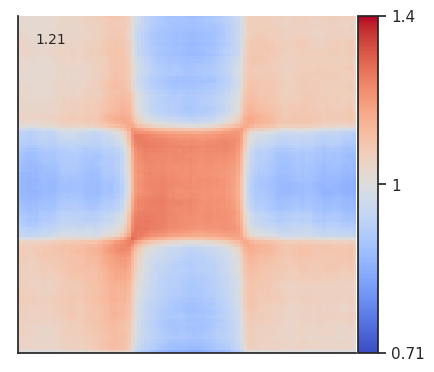

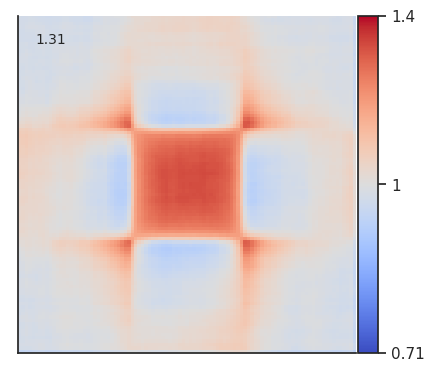

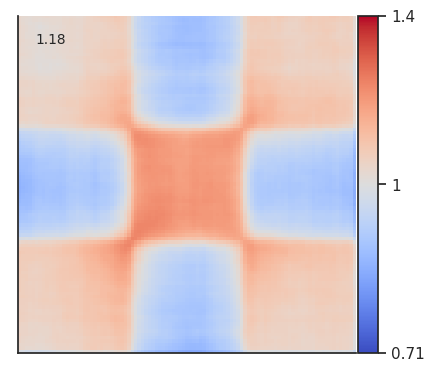

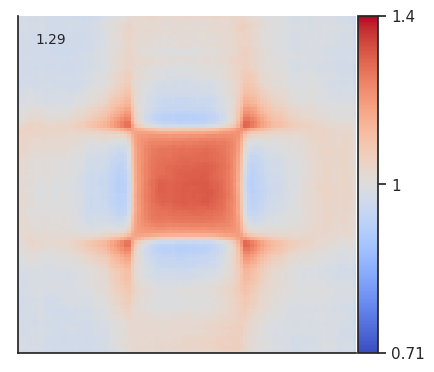

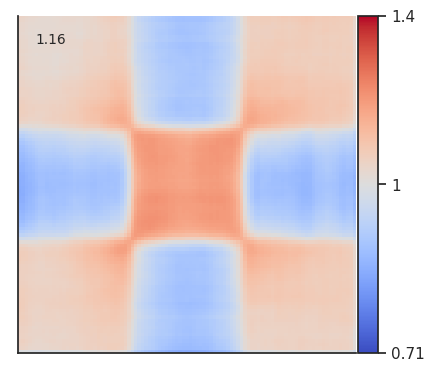

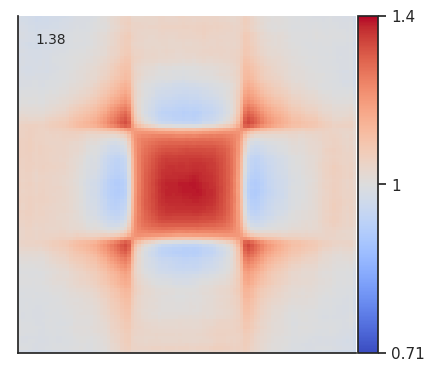

In [15]:
a_compts, b_compts = run_pileups(eig_annot, uc_coolers, uc_exp_fnames, res=resolution, nint=5, sd=savedir)